# PROJECT 1: MULTI-SCENARIO PORTFOLIO OPTIMIZER

This tool optimizes portfolio allocations based on historical data using objective metrics (Sharpe ratio, volatility, drawdowns).

**No subjective inputs are used.** All weights are determined mathematically by the optimizer.

## What You Control
- Which tickers are included
- The date range(s)
- Optimization constraints (max position %, etc.)
- Rebalancing frequency

## What The Optimizer Controls
- The weights for each asset
- The allocation between indexes and stocks (S2)

## Scenarios
- **S1: Pure Alpha** - 22 individual stocks
- **S2: Core-Satellite** - Indexes (VTI, VXUS, BND) + 22 stocks (optimized split)
- **S3: Pure Beta** - 3 indexes only (VTI, VXUS, BND) - NO max cap
- **S4: Hybrid** - 21 stocks + 3 sector ETFs (XLU, XLRE, XLC)

## Industry Standard Metrics
- Annualized Return
- Annualized Volatility
- Sharpe Ratio (using 3-month T-bill as risk-free rate)
- Maximum Drawdown

## Constraints
- No short selling (all weights >= 0)
- Fully invested (sum of weights = 100%)
- Max 10% per position (prevents concentration) - EXCEPT for S3 which has no cap
- For portfolios with fewer than 5 assets, max weight adjusts automatically to allow 100%

In [1]:
# IMPORT LIBRARIES
# ============================================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Set up inline plotting for Jupyter
%matplotlib inline

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================================
# USER CONTROLS - CHANGE THESE AS NEEDED
# ============================================================================

# Date range method: 'max_available' uses all data per ticker
USE_MAX_AVAILABLE = True

# Risk-free rate (3-month T-bill current rate as of 2024)
RISK_FREE_RATE = 0.05  # 5% annual

# Optimization objective
OPTIMIZATION_OBJECTIVE = 'sharpe'  # 'sharpe', 'min_volatility', 'max_return'

# ============================================================================
# CONSTRAINTS
# 
# The following constraints are applied to the optimizer based on industry
# standards for diversified long-only portfolios.
#
# Why these constraints:
# - No short selling: Standard for most individual investors
# - Fully invested (100%): Assumes all capital working, no cash drag  
# - Max 10% per position: Prevents optimizer from concentrating in one asset.
#   For portfolios with fewer than 5 assets, max weight adjusts automatically
#   to allow the sum to reach 100%. For S3 (3 indexes), there is NO max cap.
# ============================================================================

MAX_SINGLE_WEIGHT = 0.10  # 10% max per position
NO_SHORTING = True
FULLY_INVESTED = True

print("User controls loaded:")
print(f"  Risk-free rate: {RISK_FREE_RATE:.1%}")
print(f"  Max position: {MAX_SINGLE_WEIGHT:.0%}")
print(f"  No shorting: {NO_SHORTING}")
print(f"  Fully invested: {FULLY_INVESTED}")

User controls loaded:
  Risk-free rate: 5.0%
  Max position: 10%
  No shorting: True
  Fully invested: True


In [3]:
# ============================================================================
# TICKER DEFINITIONS
# ============================================================================

# S1 & S4 Stock Tickers (21 stocks - includes GE)
STOCK_TICKERS = [
    # Technology (3)
    'AAPL', 'MSFT', 'NVDA',
    # Healthcare (3)
    'JNJ', 'LLY', 'UNH',
    # Financials (3)
    'JPM', 'V', 'BRK-B',
    # Consumer Defensive (3)
    'PG', 'COST', 'KO',
    # Consumer Cyclical (2)
    'AMZN', 'HD',
    # Industrials (2)
    'CAT', 'GE',
    # Energy (2)
    'XOM', 'CVX',
    # Materials (1)
    'LIN'
]

# S4 Additional ETFs (3)
S4_ETF_TICKERS = ['XLU', 'XLRE', 'XLC']  # Utilities, Real Estate, Communications

# S1 Complete Tickers (22 stocks - includes GE and GOOGL)
S1_TICKERS = STOCK_TICKERS + ['GOOGL']  # Add GOOGL

# S4 Complete Tickers (21 stocks + 3 ETFs)
S4_TICKERS = STOCK_TICKERS + S4_ETF_TICKERS

# Index ETFs for S2 and S3
INDEX_TICKERS = ['VTI', 'VXUS', 'BND']

# All assets for S2 (Indexes + S1 stocks)
S2_TICKERS = INDEX_TICKERS + S1_TICKERS

print("Tickers loaded:")
print(f"  S1: {len(S1_TICKERS)} stocks")
print(f"  S2: {len(S2_TICKERS)} assets (3 indexes + {len(S1_TICKERS)} stocks)")
print(f"  S3: {len(INDEX_TICKERS)} indexes")
print(f"  S4: {len(S4_TICKERS)} assets ({len(STOCK_TICKERS)} stocks + {len(S4_ETF_TICKERS)} ETFs)")

Tickers loaded:
  S1: 20 stocks
  S2: 23 assets (3 indexes + 20 stocks)
  S3: 3 indexes
  S4: 22 assets (19 stocks + 3 ETFs)


In [4]:
# ============================================================================
# PORTFOLIO OPTIMIZER CLASS
# ============================================================================

class PortfolioOptimizer:
    """
    Portfolio optimization engine with support for constraints, rebalancing,
    and scenario analysis.
    """
    
    def __init__(self, tickers, name, start_date=None, end_date=None):
        """
        Initialize the portfolio optimizer.
        
        Parameters:
        tickers (list): List of ticker symbols
        name (str): Name of the scenario (for display)
        """
        self.tickers = tickers
        self.name = name
        self.start_date = start_date
        self.end_date = end_date
        self.data = None
        self.returns = None
        self.cov_matrix = None
        self.mean_returns = None
        self.optimal_weights = None
        self.optimal_return = None
        self.optimal_volatility = None
        self.optimal_sharpe = None
        self.max_drawdown = None
        
    def download_data(self):
        """Download historical stock data from Yahoo Finance."""
        print(f"  Downloading data for {self.name} ({len(self.tickers)} assets)...")
        
        if USE_MAX_AVAILABLE:
            self.data = yf.download(self.tickers, period='max')['Close']
        else:
            self.data = yf.download(self.tickers, start=self.start_date, 
                                   end=self.end_date)['Close']
        
        self.data.dropna(inplace=True)
        
        if USE_MAX_AVAILABLE and len(self.tickers) > 0:
            common_start = self.data.index[0]
            self.data = self.data.loc[common_start:]
        
        print(f"    Data range: {self.data.index[0].date()} to {self.data.index[-1].date()}")
        print(f"    Data shape: {self.data.shape}")
        return self.data
    
    def calculate_returns(self):
        """Calculate daily returns and statistics."""
        self.returns = self.data.pct_change().dropna()
        self.mean_returns = self.returns.mean()
        self.cov_matrix = self.returns.cov()
        return self.returns
    
    def annualized_metrics(self, weights):
        """
        Calculate annualized portfolio metrics.
        
        Returns:
        tuple: (annual_return, annual_volatility, sharpe_ratio)
        """
        portfolio_return = np.sum(self.mean_returns * weights) * 252
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix * 252, weights)))
        sharpe_ratio = (portfolio_return - RISK_FREE_RATE) / portfolio_volatility if portfolio_volatility > 0 else 0
        return portfolio_return, portfolio_volatility, sharpe_ratio
    
    def calculate_max_drawdown(self, returns_series):
        """Calculate maximum drawdown from a returns series."""
        cumulative = (1 + returns_series).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        return drawdown.min()
    
    def negative_sharpe(self, weights):
        """Negative Sharpe ratio for minimization."""
        return -self.annualized_metrics(weights)[2]
    
    def portfolio_volatility(self, weights):
        """Portfolio volatility for minimization."""
        return self.annualized_metrics(weights)[1]
    
    def negative_return(self, weights):
        """Negative return for maximization."""
        return -self.annualized_metrics(weights)[0]
    
    def optimize(self):
        """Run optimization based on the specified objective."""
        num_assets = len(self.tickers)
        
        constraints = []
        if FULLY_INVESTED:
            constraints.append({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
        
        # DYNAMIC MAX WEIGHT - automatically adjusts for small portfolios
        # Special case: S3 (3 indexes) has NO max cap
        if NO_SHORTING:
            # Check if this is S3 (Pure Beta with 3 indexes)
            if self.name == "S3: Pure Beta":
                actual_max = 1.0  # No cap for indexes
                print(f"    Note: No max weight cap applied (S3 indexes only)")
            else:
                min_possible_max = 1.0 / num_assets
                actual_max = max(MAX_SINGLE_WEIGHT, min_possible_max)
            bounds = tuple((0, actual_max) for _ in range(num_assets))
        else:
            bounds = tuple((-MAX_SINGLE_WEIGHT, MAX_SINGLE_WEIGHT) for _ in range(num_assets))
        
        initial_guess = num_assets * [1. / num_assets]
        
        if OPTIMIZATION_OBJECTIVE == 'sharpe':
            objective = self.negative_sharpe
            objective_name = "Sharpe Ratio"
        elif OPTIMIZATION_OBJECTIVE == 'min_volatility':
            objective = self.portfolio_volatility
            objective_name = "Minimum Volatility"
        else:
            objective = self.negative_return
            objective_name = "Maximum Return"
        
        print(f"    Optimizing for: {objective_name}")
        
        # Use L-BFGS-B for small portfolios (<5 assets), SLSQP for larger ones
        if len(self.tickers) <= 5:
            result = minimize(objective, initial_guess, method='L-BFGS-B',
                             bounds=bounds)
        else:
            result = minimize(objective, initial_guess, method='SLSQP',
                             bounds=bounds, constraints=constraints)
        
        if result.success:
            self.optimal_weights = result.x
            self.optimal_return, self.optimal_volatility, self.optimal_sharpe = self.annualized_metrics(result.x)
            
            portfolio_returns = np.sum(self.returns * result.x, axis=1)
            self.max_drawdown = self.calculate_max_drawdown(portfolio_returns)
            
            print(f"    Optimization successful!")
            print(f"    Return: {self.optimal_return:.2%} | Vol: {self.optimal_volatility:.2%} | Sharpe: {self.optimal_sharpe:.3f} | Max DD: {self.max_drawdown:.2%}")
        else:
            print(f"    Optimization failed: {result.message}")
            self.optimal_weights = initial_guess
        
        return self.optimal_weights
    
    def generate_random_portfolios(self, num_portfolios=5000):
        """Generate random portfolios for efficient frontier visualization."""
        returns = []
        volatilities = []
        sharpe_ratios = []
        weights_list = []
        
        num_assets = len(self.tickers)
        
        for _ in range(num_portfolios):
            weights = np.random.random(num_assets)
            weights /= np.sum(weights)
            ret, vol, sharpe = self.annualized_metrics(weights)
            
            returns.append(ret)
            volatilities.append(vol)
            sharpe_ratios.append(sharpe)
            weights_list.append(weights)
        
        return returns, volatilities, sharpe_ratios, weights_list
    
    def print_summary(self):
        """Print detailed portfolio summary."""
        if self.optimal_weights is None:
            print("Run optimize() first.")
            return
        
        print(f"\n{'='*60}")
        print(f"{self.name} - OPTIMAL PORTFOLIO SUMMARY")
        print(f"{'='*60}")
        print(f"Expected Annual Return:     {self.optimal_return:.2%}")
        print(f"Expected Annual Volatility: {self.optimal_volatility:.2%}")
        print(f"Sharpe Ratio:               {self.optimal_sharpe:.3f}")
        print(f"Maximum Drawdown:           {self.max_drawdown:.2%}")
        print(f"\nAsset Allocation:")
        
        # Sort by weight (descending)
        sorted_weights = sorted(zip(self.tickers, self.optimal_weights), 
                               key=lambda x: x[1], reverse=True)
        
        for ticker, weight in sorted_weights:
            if weight > 0.001:
                print(f"  {ticker:8s}: {weight:.2%}")
        
        print(f"{'='*60}\n")

print("PortfolioOptimizer class loaded successfully!")

PortfolioOptimizer class loaded successfully!


In [5]:
# ============================================================================
# CORE-SATELLITE OPTIMIZER (Indexes + Individual Stocks)
# ============================================================================

class CoreSatelliteOptimizer:
    """
    Specialized optimizer for S2 that finds optimal allocation between
    index funds and individual stocks.
    """
    
    def __init__(self, index_tickers, stock_tickers, name, start_date=None, end_date=None):
        self.index_tickers = index_tickers
        self.stock_tickers = stock_tickers
        self.all_tickers = index_tickers + stock_tickers
        self.name = name
        self.start_date = start_date
        self.end_date = end_date
        self.data = None
        self.returns = None
        self.cov_matrix = None
        self.mean_returns = None
        self.optimal_weights = None
        
    def download_data(self):
        """Download historical data for all assets."""
        print(f"  Downloading data for {self.name} ({len(self.all_tickers)} assets)...")
        
        if USE_MAX_AVAILABLE:
            self.data = yf.download(self.all_tickers, period='max')['Close']
        else:
            self.data = yf.download(self.all_tickers, start=self.start_date, 
                                   end=self.end_date)['Close']
        
        self.data.dropna(inplace=True)
        
        if USE_MAX_AVAILABLE and len(self.all_tickers) > 0:
            common_start = self.data.index[0]
            self.data = self.data.loc[common_start:]
        
        print(f"    Data range: {self.data.index[0].date()} to {self.data.index[-1].date()}")
        return self.data
    
    def calculate_returns(self):
        """Calculate daily returns."""
        self.returns = self.data.pct_change().dropna()
        self.mean_returns = self.returns.mean()
        self.cov_matrix = self.returns.cov()
        return self.returns
    
    def annualized_metrics(self, weights):
        """Calculate annualized portfolio metrics."""
        portfolio_return = np.sum(self.mean_returns * weights) * 252
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix * 252, weights)))
        sharpe_ratio = (portfolio_return - RISK_FREE_RATE) / portfolio_volatility if portfolio_volatility > 0 else 0
        return portfolio_return, portfolio_volatility, sharpe_ratio
    
    def negative_sharpe(self, weights):
        """Negative Sharpe ratio for minimization."""
        return -self.annualized_metrics(weights)[2]
    
    def optimize(self):
        """Run optimization across all assets (indexes + stocks)."""
        num_assets = len(self.all_tickers)
        
        constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
        
        # DYNAMIC MAX WEIGHT - automatically adjusts for small portfolios
        if NO_SHORTING:
            min_possible_max = 1.0 / num_assets
            actual_max = max(MAX_SINGLE_WEIGHT, min_possible_max)
            bounds = tuple((0, actual_max) for _ in range(num_assets))
        else:
            bounds = tuple((-MAX_SINGLE_WEIGHT, MAX_SINGLE_WEIGHT) for _ in range(num_assets))
        
        initial_guess = num_assets * [1. / num_assets]
        
        # Use L-BFGS-B for small portfolios (<5 assets), SLSQP for larger ones
        if num_assets <= 5:
            result = minimize(self.negative_sharpe, initial_guess, method='L-BFGS-B',
                             bounds=bounds)
        else:
            result = minimize(self.negative_sharpe, initial_guess, method='SLSQP',
                             bounds=bounds, constraints=constraints)
        
        if result.success:
            self.optimal_weights = result.x
            ret, vol, sharpe = self.annualized_metrics(result.x)
            
            # Calculate index vs stock allocation
            index_weight = np.sum(result.x[:len(self.index_tickers)])
            stock_weight = np.sum(result.x[len(self.index_tickers):])
            
            print(f"    Optimization successful!")
            print(f"    Index allocation: {index_weight:.2%} | Stock allocation: {stock_weight:.2%}")
            print(f"    Return: {ret:.2%} | Vol: {vol:.2%} | Sharpe: {sharpe:.3f}")
        else:
            print(f"    Optimization failed: {result.message}")
            self.optimal_weights = initial_guess
        
        return self.optimal_weights
    
    def print_summary(self):
        """Print detailed portfolio summary."""
        if self.optimal_weights is None:
            print("Run optimize() first.")
            return
        
        ret, vol, sharpe = self.annualized_metrics(self.optimal_weights)
        
        print(f"\n{'='*60}")
        print(f"{self.name} - OPTIMAL PORTFOLIO SUMMARY")
        print(f"{'='*60}")
        print(f"Expected Annual Return:     {ret:.2%}")
        print(f"Expected Annual Volatility: {vol:.2%}")
        print(f"Sharpe Ratio:               {sharpe:.3f}")
        print(f"\nAsset Allocation:")
        
        print("\n  INDEX COMPONENT:")
        for i, ticker in enumerate(self.index_tickers):
            weight = self.optimal_weights[i]
            if weight > 0.001:
                print(f"    {ticker:8s}: {weight:.2%}")
        
        print("\n  STOCK COMPONENT (top 10 by weight):")
        stock_weights = [(self.stock_tickers[j], self.optimal_weights[len(self.index_tickers) + j]) 
                        for j in range(len(self.stock_tickers))]
        stock_weights.sort(key=lambda x: x[1], reverse=True)
        
        for ticker, weight in stock_weights[:10]:
            if weight > 0.001:
                print(f"    {ticker:8s}: {weight:.2%}")
        
        if len(stock_weights) > 10:
            remaining = sum(w for _, w in stock_weights[10:])
            print(f"    {'Others':8s}: {remaining:.2%}")
        
        print(f"{'='*60}\n")

print("CoreSatelliteOptimizer class loaded successfully!")

CoreSatelliteOptimizer class loaded successfully!


In [6]:
# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_efficient_frontier(optimizer, title):
    """
    Plot efficient frontier with optimal portfolio highlighted.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Generate random portfolios
    returns, volatilities, sharpe_ratios, _ = optimizer.generate_random_portfolios(3000)
    
    # Scatter plot of random portfolios
    scatter = ax.scatter(volatilities, returns, c=sharpe_ratios, 
                        cmap='viridis', alpha=0.5, s=10)
    plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')
    
    # Mark optimal portfolio
    ax.scatter(optimizer.optimal_volatility, optimizer.optimal_return, 
              c='red', s=200, marker='*', label='Optimal Portfolio', zorder=5)
    
    ax.set_xlabel('Annualized Volatility (Risk)')
    ax.set_ylabel('Annualized Return')
    ax.set_title(f'{title}\nSharpe: {optimizer.optimal_sharpe:.3f} | Return: {optimizer.optimal_return:.2%} | Risk: {optimizer.optimal_volatility:.2%}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return fig

def plot_cumulative_returns(optimizer, title):
    """
    Plot cumulative returns of the optimal portfolio.
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    
    if optimizer.optimal_weights is None:
        print(f"Cannot plot cumulative returns for {title} - run optimize first.")
        return fig
    
    portfolio_returns = np.sum(optimizer.returns * optimizer.optimal_weights, axis=1)
    cumulative = (1 + portfolio_returns).cumprod()
    
    ax.plot(cumulative.index, cumulative, linewidth=2, color='blue')
    ax.fill_between(cumulative.index, 1, cumulative, alpha=0.3, color='blue')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return ($1 invested)')
    ax.set_title(f'{title} - Cumulative Returns\nFinal Value: ${cumulative.iloc[-1]:.2f}')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1, color='black', linestyle='-', linewidth=0.5)
    
    return fig

def plot_drawdown(optimizer, title):
    """
    Plot drawdown over time for the optimal portfolio.
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    
    if optimizer.optimal_weights is None:
        print(f"Cannot plot drawdown for {title} - run optimize first.")
        return fig
    
    portfolio_returns = np.sum(optimizer.returns * optimizer.optimal_weights, axis=1)
    cumulative = (1 + portfolio_returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    
    ax.fill_between(drawdown.index, 0, drawdown, color='red', alpha=0.5)
    ax.plot(drawdown.index, drawdown, color='darkred', linewidth=1)
    ax.set_xlabel('Date')
    ax.set_ylabel('Drawdown')
    ax.set_title(f'{title} - Maximum Drawdown: {optimizer.max_drawdown:.2%}')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    return fig

def plot_correlation_heatmap(optimizer, title):
    """
    Plot correlation heatmap of assets.
    """
    fig, ax = plt.subplots(figsize=(12, 10))
    
    correlation_matrix = optimizer.returns.corr()
    
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
               square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, 
               ax=ax, fmt='.2f', annot_kws={'size': 8})
    ax.set_title(f'{title} - Asset Correlation Matrix')
    
    return fig

def plot_weights_pie(optimizer, title):
    """
    Plot pie chart of optimal portfolio weights.
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    if optimizer.optimal_weights is None:
        print(f"Cannot plot weights for {title} - run optimize first.")
        return fig
    
    # Filter out weights below 1%
    non_zero = [(ticker, weight) for ticker, weight in zip(optimizer.tickers, optimizer.optimal_weights) 
                if weight > 0.01]
    
    if not non_zero:
        non_zero = [(ticker, weight) for ticker, weight in zip(optimizer.tickers, optimizer.optimal_weights)]
    
    tickers_filtered = [t[0] for t in non_zero]
    weights_filtered = [t[1] for t in non_zero]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(tickers_filtered)))
    
    ax.pie(weights_filtered, labels=tickers_filtered, autopct='%1.1f%%', colors=colors, startangle=90)
    ax.set_title(f'{title} - Optimal Portfolio Weights\nSharpe: {optimizer.optimal_sharpe:.3f}')
    
    return fig

print("Visualization functions loaded successfully!")

Visualization functions loaded successfully!



SCENARIO 1: Pure Alpha (22 Individual Stocks)


[*********************100%***********************]  20 of 20 completed


    Data range: 2008-03-19 to 2026-05-01
    Data shape: (4559, 20)
    Optimizing for: Sharpe Ratio
    Optimization successful!
    Return: 24.73% | Vol: 20.71% | Sharpe: 0.952 | Max DD: -48.55%

S1: Pure Alpha - OPTIMAL PORTFOLIO SUMMARY
Expected Annual Return:     24.73%
Expected Annual Volatility: 20.71%
Sharpe Ratio:               0.952
Maximum Drawdown:           -48.55%

Asset Allocation:
  MSFT    : 10.00%
  LLY     : 10.00%
  HD      : 10.00%
  GE      : 10.00%
  AAPL    : 10.00%
  LIN     : 10.00%
  V       : 10.00%
  PG      : 9.07%
  BRK-B   : 8.36%
  CVX     : 7.29%
  JNJ     : 5.28%



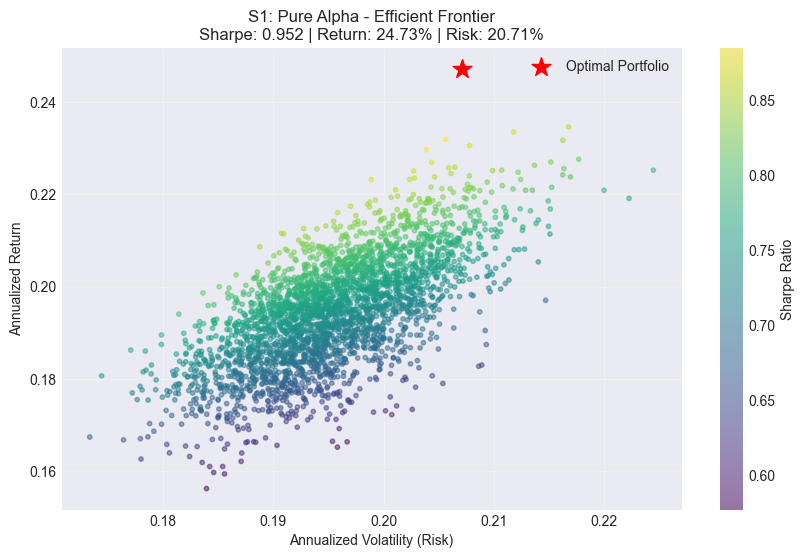

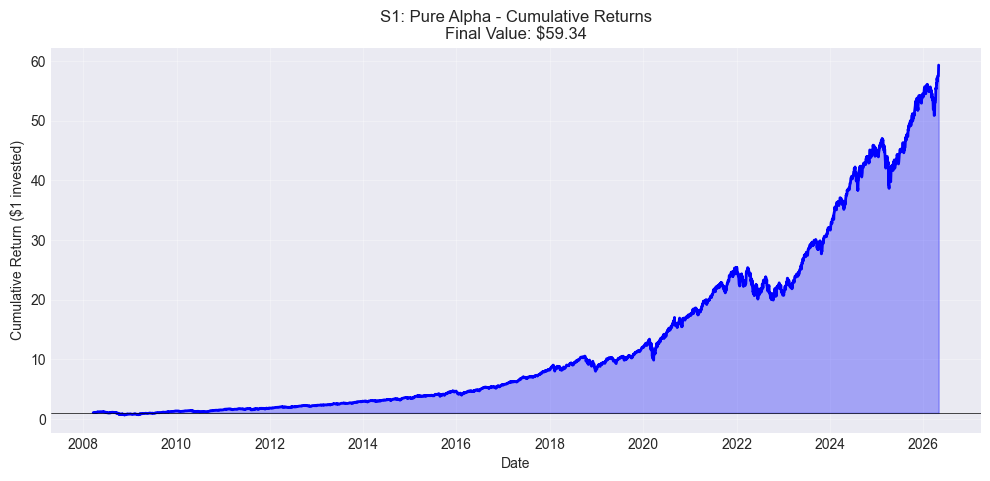

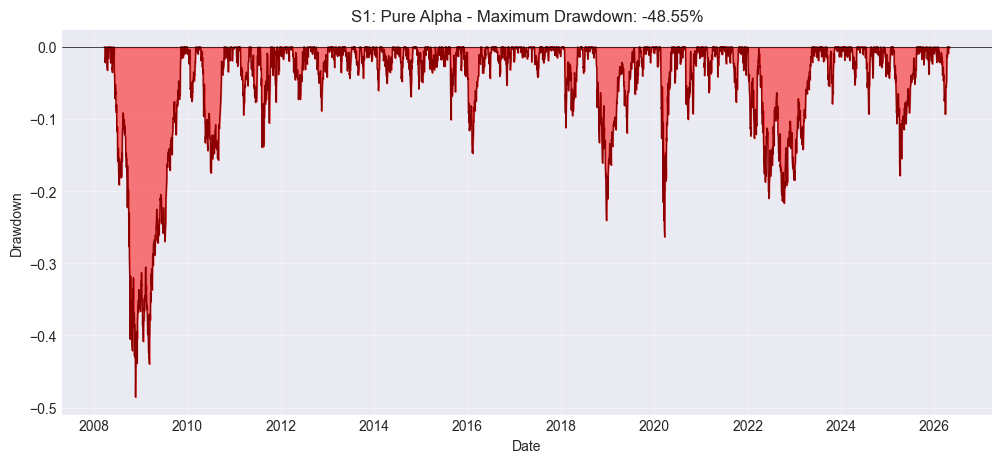

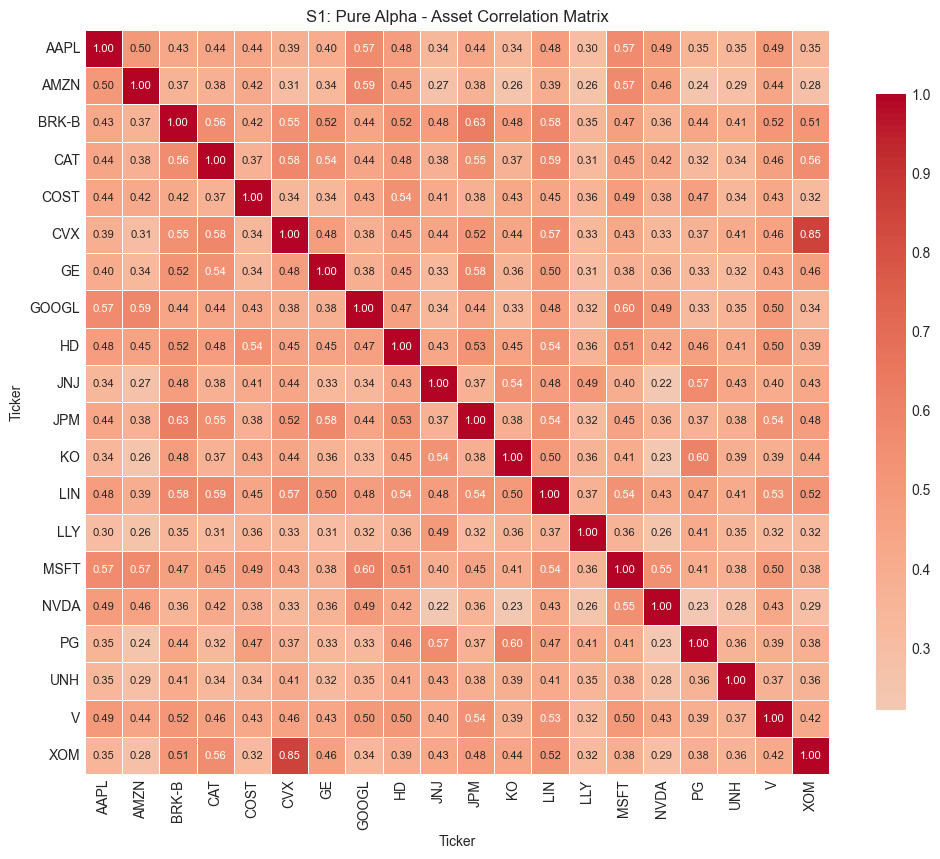

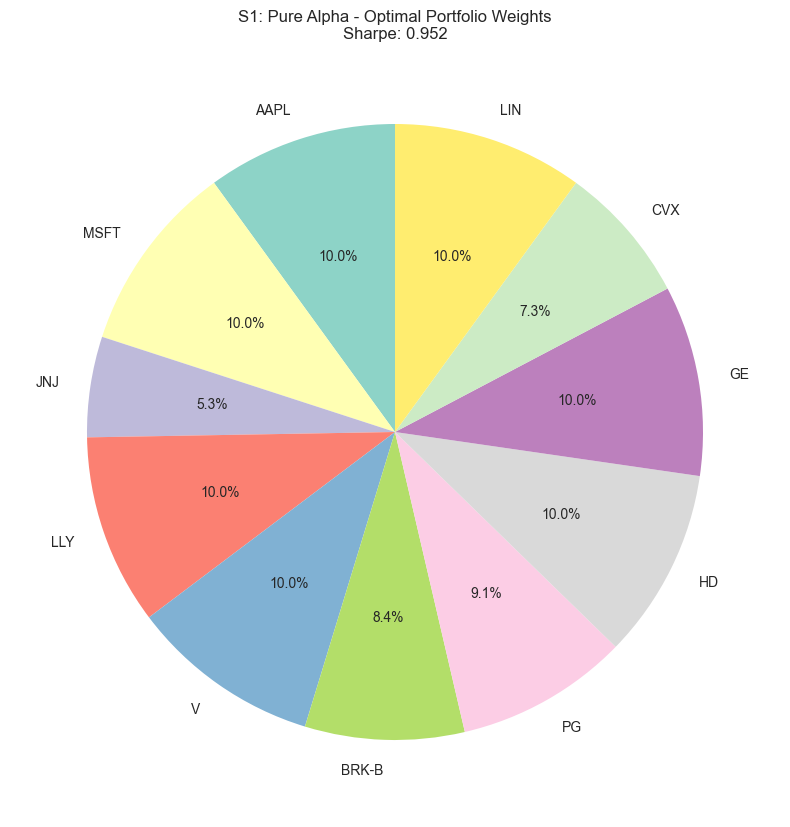

In [7]:
# ============================================================================
# SCENARIO 1: Pure Alpha (22 individual stocks - includes GE)
# ============================================================================

print("\n" + "="*80)
print("SCENARIO 1: Pure Alpha (22 Individual Stocks)")
print("="*80)

s1 = PortfolioOptimizer(S1_TICKERS, "S1: Pure Alpha")
s1.download_data()
s1.calculate_returns()
s1.optimize()
s1.print_summary()

# Generate S1 Charts - These will appear right here
plot_efficient_frontier(s1, "S1: Pure Alpha - Efficient Frontier")
plt.show()

plot_cumulative_returns(s1, "S1: Pure Alpha")
plt.show()

plot_drawdown(s1, "S1: Pure Alpha")
plt.show()

plot_correlation_heatmap(s1, "S1: Pure Alpha")
plt.show()

plot_weights_pie(s1, "S1: Pure Alpha")
plt.show()

In [8]:
# ============================================================================
# SCENARIO 2: Core-Satellite (Indexes + Individual Stocks)
# ============================================================================

print("\n" + "="*80)
print("SCENARIO 2: Core-Satellite (Indexes + Individual Stocks)")
print("="*80)

s2 = CoreSatelliteOptimizer(INDEX_TICKERS, S1_TICKERS, "S2: Core-Satellite")
s2.download_data()
s2.calculate_returns()
s2.optimize()
s2.print_summary()


SCENARIO 2: Core-Satellite (Indexes + Individual Stocks)


[*********************100%***********************]  23 of 23 completed


    Data range: 2011-01-28 to 2026-05-01
    Optimization successful!
    Index allocation: 20.55% | Stock allocation: 79.45%
    Return: 25.29% | Vol: 18.14% | Sharpe: 1.119

S2: Core-Satellite - OPTIMAL PORTFOLIO SUMMARY
Expected Annual Return:     25.29%
Expected Annual Volatility: 18.14%
Sharpe Ratio:               1.119

Asset Allocation:

  INDEX COMPONENT:
    VTI     : 10.00%
    VXUS    : 10.00%
    BND     : 0.55%

  STOCK COMPONENT (top 10 by weight):
    NVDA    : 10.00%
    V       : 10.00%
    HD      : 10.00%
    XOM     : 10.00%
    GE      : 10.00%
    KO      : 10.00%
    UNH     : 9.46%
    MSFT    : 5.33%
    JPM     : 4.65%
    Others  : 0.00%




SCENARIO 3: Pure Beta (3 Indexes Only - NO MAX CAP)


[*********************100%***********************]  3 of 3 completed


    Data range: 2011-01-28 to 2026-05-01
    Data shape: (3837, 3)
    Note: No max weight cap applied (S3 indexes only)
    Optimizing for: Sharpe Ratio
    Optimization successful!
    Return: 16.78% | Vol: 18.37% | Sharpe: 0.641 | Max DD: -37.47%

S3: Pure Beta - OPTIMAL PORTFOLIO SUMMARY
Expected Annual Return:     16.78%
Expected Annual Volatility: 18.37%
Sharpe Ratio:               0.641
Maximum Drawdown:           -37.47%

Asset Allocation:
  VTI     : 100.00%
  VXUS    : 100.00%



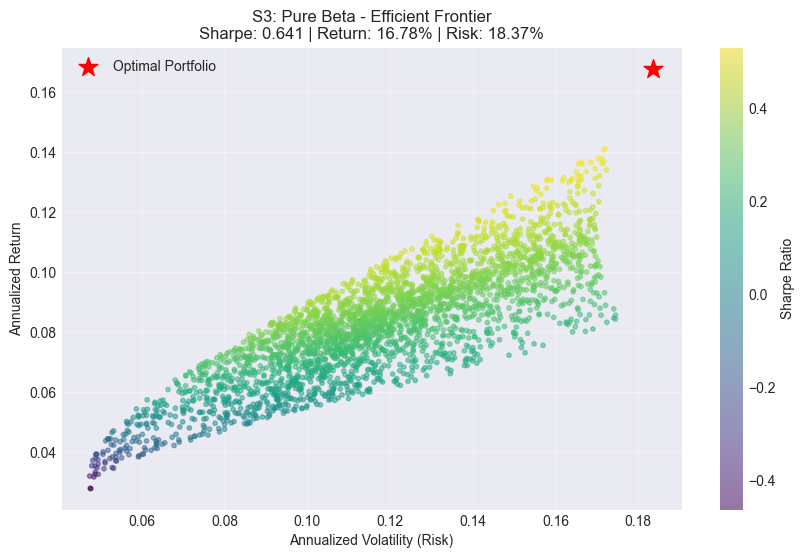

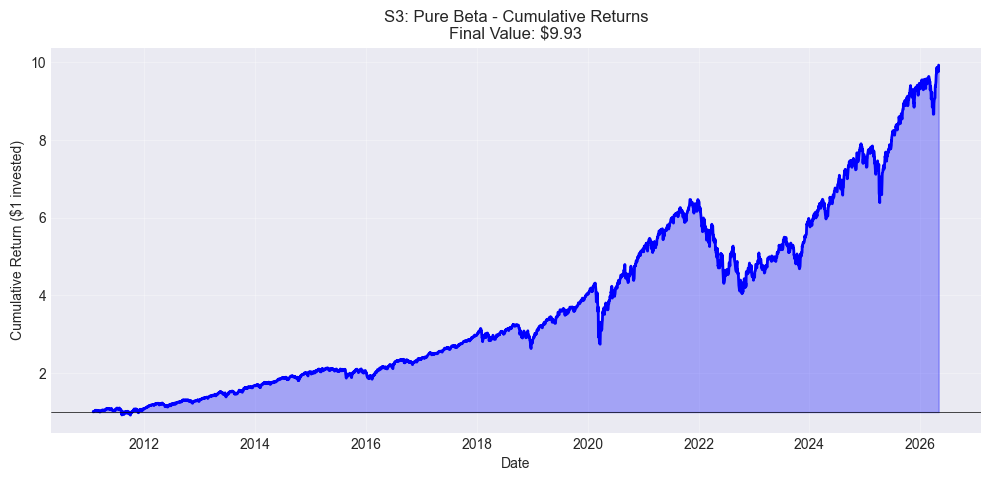

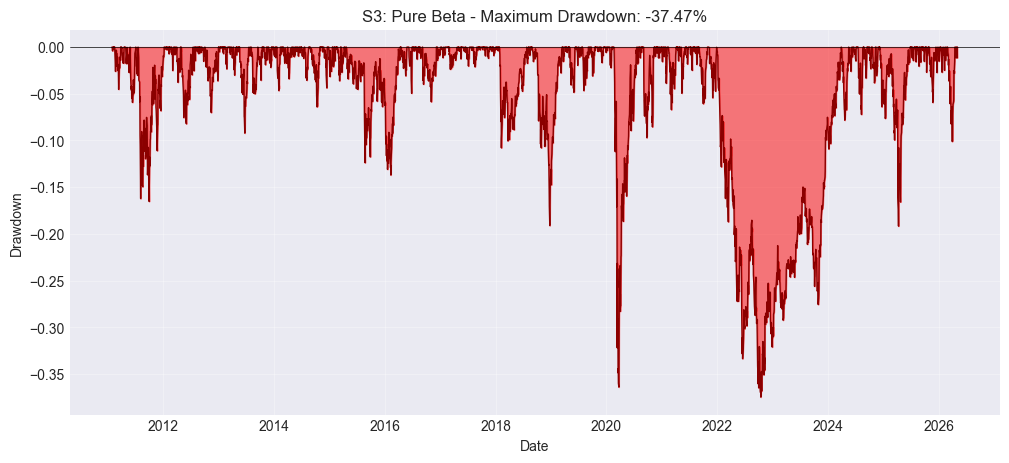

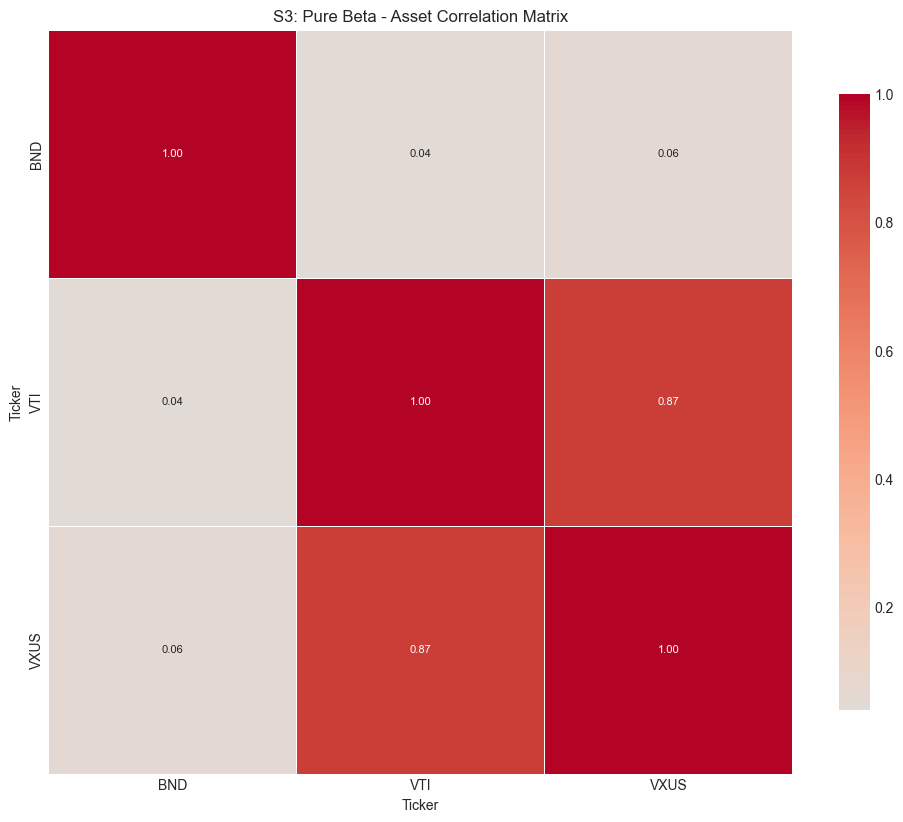

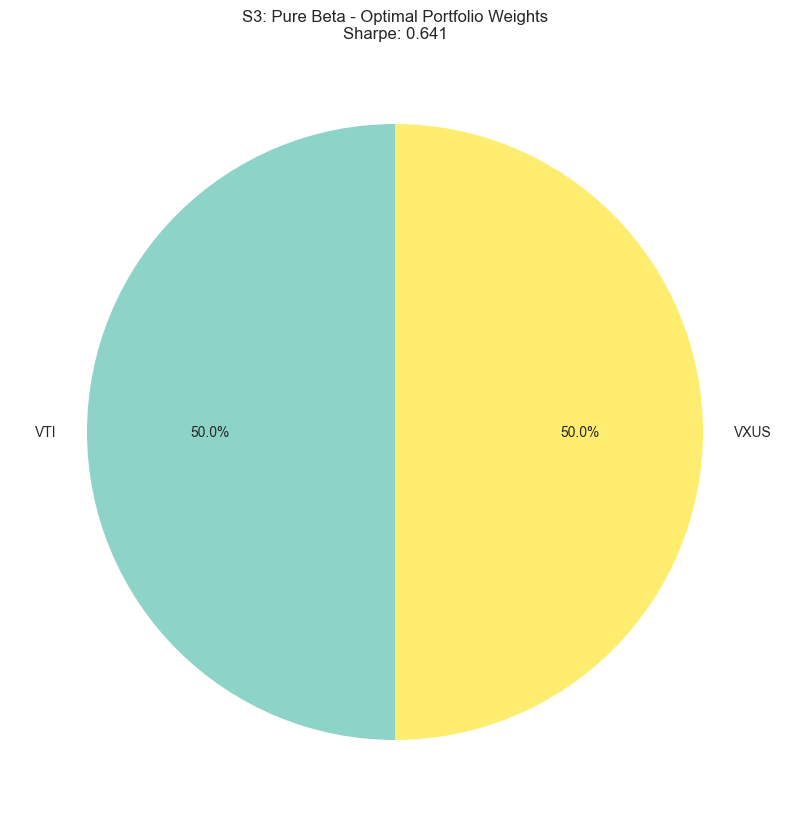

In [9]:
# ============================================================================
# SCENARIO 3: Pure Beta (3 Indexes Only - NO MAX CAP)
# ============================================================================

print("\n" + "="*80)
print("SCENARIO 3: Pure Beta (3 Indexes Only - NO MAX CAP)")
print("="*80)

s3 = PortfolioOptimizer(INDEX_TICKERS, "S3: Pure Beta")
s3.download_data()
s3.calculate_returns()
s3.optimize()
s3.print_summary()

# Generate S3 Charts - These will appear right here
plot_efficient_frontier(s3, "S3: Pure Beta - Efficient Frontier")
plt.show()

plot_cumulative_returns(s3, "S3: Pure Beta")
plt.show()

plot_drawdown(s3, "S3: Pure Beta")
plt.show()

plot_correlation_heatmap(s3, "S3: Pure Beta")
plt.show()

plot_weights_pie(s3, "S3: Pure Beta")
plt.show()

[                       0%                       ]


SCENARIO 4: Hybrid (21 Stocks + 3 Sector ETFs)


[*********************100%***********************]  22 of 22 completed


    Data range: 2018-06-19 to 2026-05-01
    Data shape: (1978, 22)
    Optimizing for: Sharpe Ratio
    Optimization successful!
    Return: 26.40% | Vol: 18.85% | Sharpe: 1.135 | Max DD: -29.32%

S4: Hybrid - OPTIMAL PORTFOLIO SUMMARY
Expected Annual Return:     26.40%
Expected Annual Volatility: 18.85%
Sharpe Ratio:               1.135
Maximum Drawdown:           -29.32%

Asset Allocation:
  JNJ     : 10.00%
  LLY     : 10.00%
  BRK-B   : 10.00%
  CAT     : 10.00%
  AMZN    : 10.00%
  GE      : 10.00%
  AAPL    : 10.00%
  KO      : 8.87%
  JPM     : 7.90%
  COST    : 5.83%
  XLC     : 4.27%
  HD      : 3.12%



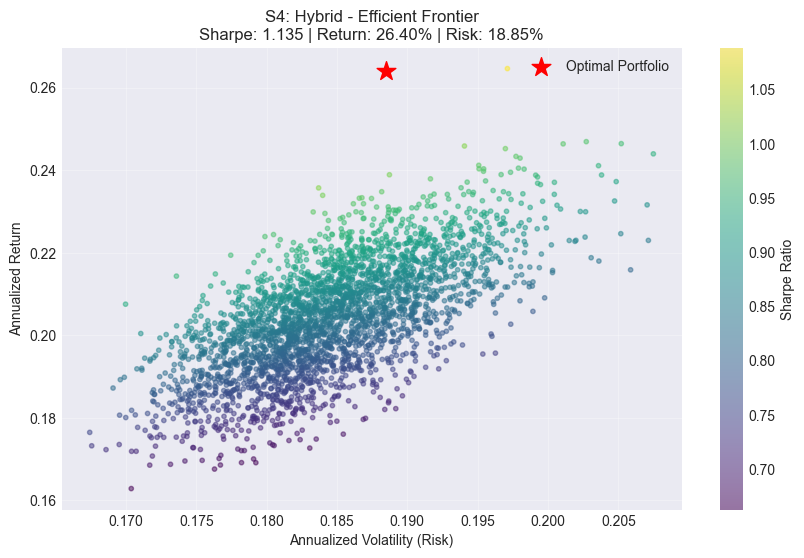

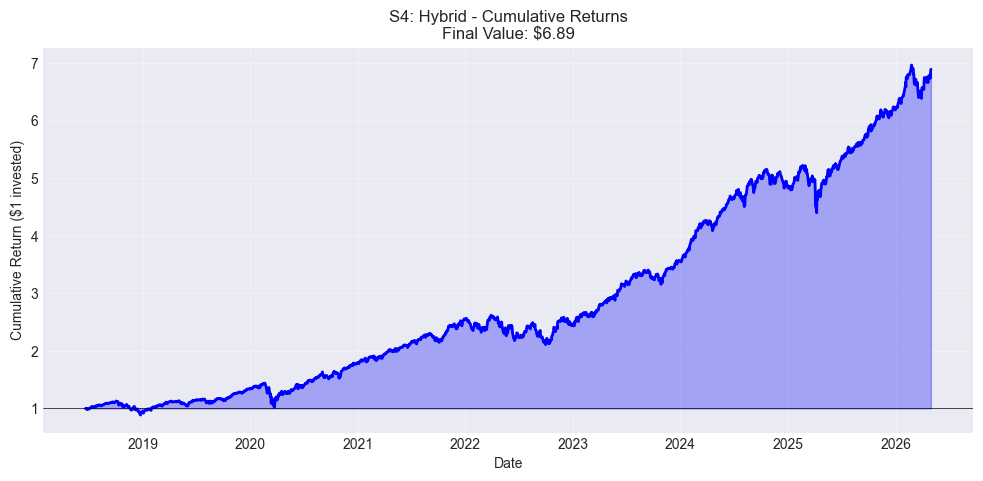

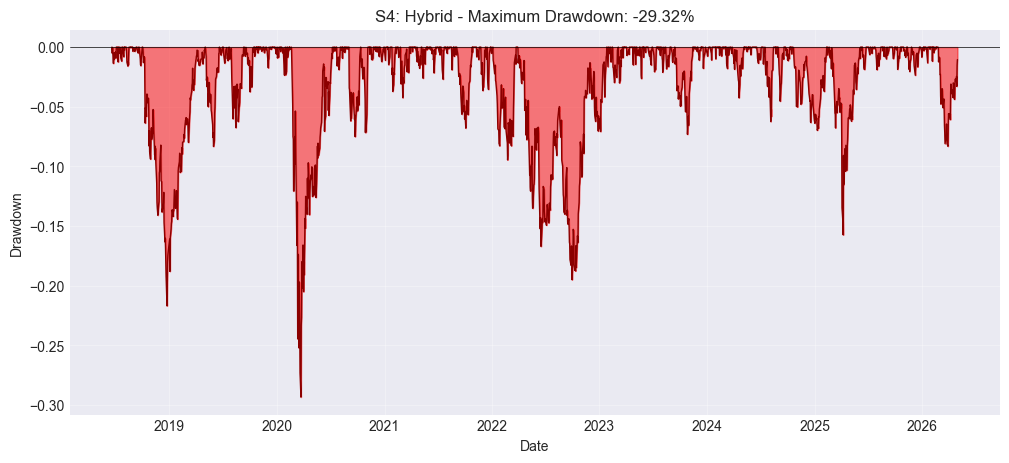

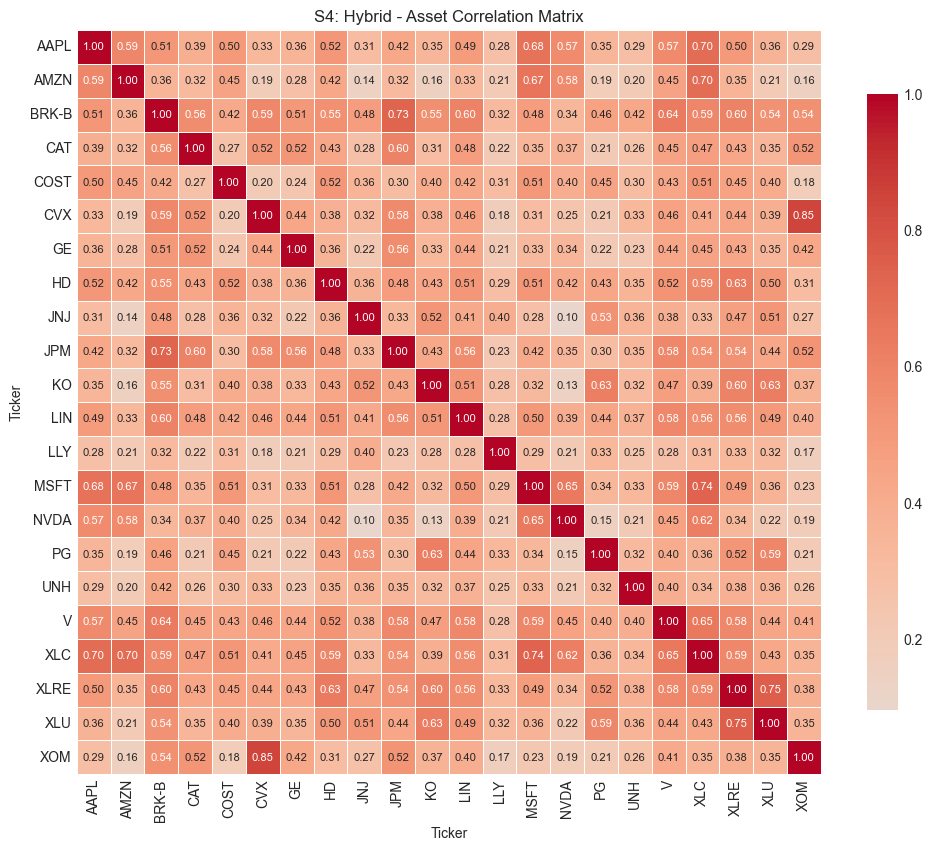

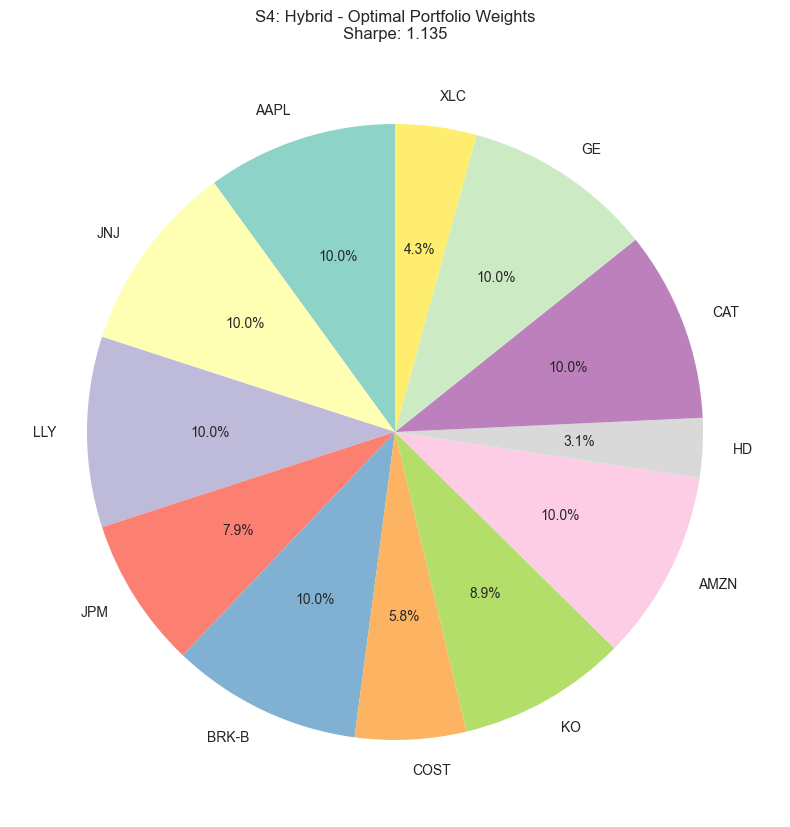


PROJECT COMPLETE - All charts generated


In [10]:
# ============================================================================
# SCENARIO 4: Hybrid (21 Stocks + 3 Sector ETFs)
# ============================================================================

print("\n" + "="*80)
print("SCENARIO 4: Hybrid (21 Stocks + 3 Sector ETFs)")
print("="*80)

s4 = PortfolioOptimizer(S4_TICKERS, "S4: Hybrid")
s4.download_data()
s4.calculate_returns()
s4.optimize()
s4.print_summary()

# Generate S4 Charts - These will appear right here
plot_efficient_frontier(s4, "S4: Hybrid - Efficient Frontier")
plt.show()

plot_cumulative_returns(s4, "S4: Hybrid")
plt.show()

plot_drawdown(s4, "S4: Hybrid")
plt.show()

plot_correlation_heatmap(s4, "S4: Hybrid")
plt.show()

plot_weights_pie(s4, "S4: Hybrid")
plt.show()

print("\n" + "="*80)
print("PROJECT COMPLETE - All charts generated")
print("="*80)